In [1]:
# mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [37]:
import pandas as pd

all_labels = pd.read_csv("/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/updated_l1l4/all.csv")
y_true_labels = all_labels["label"].to_list()
all_labels

,id,text,index,image_id,keyword_model_label,model_label,label
0,1,Figure 3.19: Relationship between the stringen...,0,112,L2,L2,['L2']
1,2,Figure 1.6: Comparison of global mean temperat...,1,126,L2,L2,['L3']
2,3,The CMIP5 multimodel ensemble (orange range) i...,2,126,L2,L2,"['L1', 'L2']"
3,4,The shaded region shows the +/- two standard d...,3,126,L2,L2,['L1']
4,5,The dashed lines show the range from maximum t...,4,126,L2,L2,['L1']
...,...,...,...,...,...,...,...
958,1207,"Figure 3.7: Global cropland (a), forest land (...",1206,2364,L1,L2,['L1']
959,1208,Notes: shaded areas indicate SRES scenario ran...,1207,2364,L1,L2,['L1']
960,1209,IMAGE-EMF21 = Van Vuuren et al.,1208,2364,L1,L2,['L1']
961,1210,(2006a) scenario from EMF-21 Study; IMAGE-MA-x...,1209,2364,L1,L2,['L1']


In [3]:
import torch
import torch.nn as nn
from transformers import BertModel

class BiLSTMWithBERT(nn.Module):
    def __init__(self, hidden_dim, num_labels, unfreeze_last=2):
        super(BiLSTMWithBERT, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for name, param in self.bert.named_parameters():
            param.requires_grad = False
            for layer_idx in range(12 - unfreeze_last, 12):
                if f"encoder.layer.{layer_idx}" in name or "pooler" in name:
                    param.requires_grad = True

        self.lstm    = nn.LSTM(
            input_size  = 768,
            hidden_size = hidden_dim,
            bidirectional= True,
            batch_first = True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, attention_mask):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        x = bert_out.last_hidden_state
        lstm_out, _ = self.lstm(x)
        pooled = torch.mean(lstm_out, dim=1)
        dropped = self.dropout(pooled)
        logits  = self.fc(dropped)
        return logits


In [4]:
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained("/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/bilstm/checkpoint/tokenizer/")

def encode_texts(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

In [5]:
ckpt = torch.load("/content/drive/Shareddrives/NiiV/NiiV Projects/Multi-modal_interpretation/data/analysis/sentence_labeling/automating_L1L4_label/bilstm.pth", map_location="cpu")

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer

classes = ckpt["mlb_classes"]
mlb_test = MultiLabelBinarizer(classes=classes)
dummy = [[c] for c in classes]
mlb_test.fit(dummy)
test_label_lists = all_labels["label"].tolist()
y_true = mlb_test.transform(test_label_lists)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) [' ', "'", ',', '1', '2', '3', '4', 'L', '[', ']'] will be ignored
  warnings.warn(


In [7]:
from transformers import BertTokenizerFast
from sklearn.preprocessing import MultiLabelBinarizer
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, hamming_loss
import matplotlib.pyplot as plt
import seaborn as sns


model = BiLSTMWithBERT(
    hidden_dim    = ckpt["hidden_dim"],
    num_labels    = ckpt["num_labels"],
    unfreeze_last = ckpt["unfreeze_last"]
)
model.load_state_dict(ckpt["model_state"])


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

test_tokenized = encode_texts(all_labels["text"].tolist())
test_input_ids = test_tokenized["input_ids"]
test_attention_mask = test_tokenized["attention_mask"]

mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(all_labels["label"].apply(lambda x: [x]))
labels_tensor  = torch.tensor(labels, dtype=torch.float)

dataset = TensorDataset(test_input_ids, test_attention_mask, labels_tensor)
val_loader = DataLoader(dataset, batch_size=16, shuffle=True)

val_correct = 0
val_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, label_batch in val_loader:
        input_ids, attention_mask, label_batch = (
            input_ids.to(device),
            attention_mask.to(device),
            label_batch.to(device)
        )

    logits = model(test_input_ids.to(device), test_attention_mask.to(device))
    probs  = torch.sigmoid(logits).cpu().numpy()

y_true = labels_tensor.numpy()
threshold = 0.5
y_pred = (probs >= threshold).astype(int)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [13]:
y_true

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [24]:
import numpy as np

def labels_from_probs(probs: np.ndarray, threshold: float = 0.6) -> list[list[str]]:
    """
    Convert a 2D array of probabilities into a list of label‐lists.
    For each row in `probs`, include "L<index+1>" for every entry >= threshold.
    """
    result = []
    for row in probs:
        high_idxs = [i for i, p in enumerate(row) if p >= threshold]
        if high_idxs:
            row_labels = [f"L{i+1}" for i in high_idxs]
        else:
            max_i = int(np.argmax(row))
            row_labels = [f"L{max_i+1}"]
        result.append(row_labels)
    return result

In [32]:
y_pred_labels = labels_from_probs(probs)
y_pred = mlb.transform(y_pred_labels)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['L1', 'L2', 'L3', 'L4'] will be ignored
  warnings.warn(


In [33]:
ham_loss = hamming_loss(y_true, y_pred)
print(f"Hamming loss: {ham_loss:.4f}")
print(f"Hamming accuracy: {1 - ham_loss:.4f}")

Hamming loss: 0.0769
Hamming accuracy: 0.9231


In [61]:
def f1_from_confusion(tp: int, tn: int, fp: int, fn: int) -> float:
    """
    Calculate the F1 score given a confusion matrix's components.

    Args:
        tp: True positives
        tn: True negatives (not used in F1 calc, but included for completeness)
        fp: False positives
        fn: False negatives

    Returns:
        F1 score (0.0 if both precision and recall are zero)
    """
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

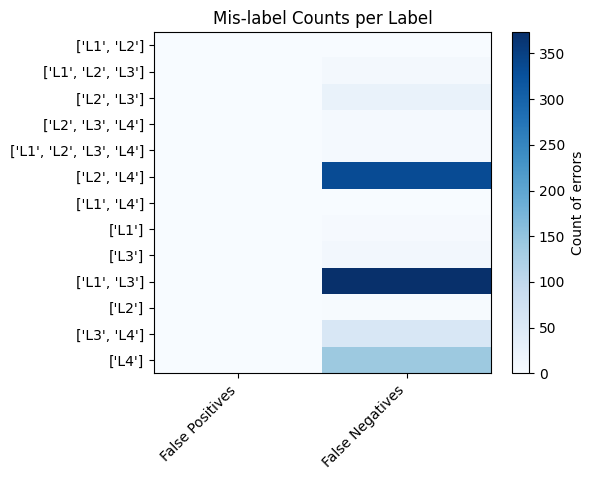

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import multilabel_confusion_matrix

label_names = list(set(y_true_labels))
cms = multilabel_confusion_matrix(y_true, y_pred)

errors = np.array([[cm[0,1], cm[1,0]] for cm in cms])

df_err = pd.DataFrame(
    errors,
    index=label_names,
    columns=["False Positives", "False Negatives"]
)

plt.figure(figsize=(6, len(label_names)*0.3 + 1))
plt.title("Mis‐label Counts per Label")
plt.imshow(df_err, aspect="auto", cmap="Blues")
plt.yticks(np.arange(len(label_names)), label_names)
plt.xticks([0,1], df_err.columns, rotation=45, ha="right")
plt.colorbar(label="Count of errors")
plt.xlabel("")
plt.tight_layout()
plt.show()


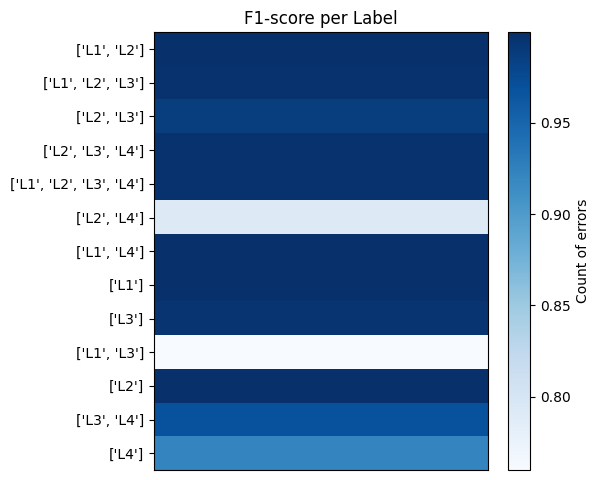

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import multilabel_confusion_matrix

label_names = list(set(y_true_labels))
cms = multilabel_confusion_matrix(y_true, y_pred)

f1_scores = np.array([f1_from_confusion(cm[0,0], cm[1,1], cm[0,1], cm[1,0]) for cm in cms])

df_f1 = pd.DataFrame(
    f1_scores,
    index=label_names,
)

plt.figure(figsize=(6, len(label_names)*0.3 + 1))
plt.title("F1-score per Label")
plt.imshow(df_f1, aspect="auto", cmap="Blues")
plt.yticks(np.arange(len(label_names)), label_names)
plt.xticks([])
plt.colorbar(label="Count of errors")
plt.xlabel("")
plt.tight_layout()
plt.show()